# PseudoVelo Case 2 - Comprehensive Evaluation and Robustness Analysis

In [1]:
import warnings, sys, os
import logging

def customwarn(message, category, filename, lineno, file=None, line=None):
    pass
warnings.showwarning = customwarn
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message="No data for colormapping provided via 'c'.*")
warnings.filterwarnings("ignore", message=".*Negative binomial dispersion parameter alpha not set.*")
warnings.filterwarnings("ignore", module="statsmodels.*")
warnings.filterwarnings("ignore", category=DeprecationWarning)
logging.getLogger().setLevel(logging.ERROR) 
os.environ['PYTHONWARNINGS'] = 'ignore'

import scanpy as sc
sc.settings.verbosity = 0 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pseudovelo as pv
import cellrank as cr
from cellmapper import CellMapper
from cellrank.kernels import CytoTRACEKernel
from transition import evaluate_transition_accuracy, projection_consistency, cross_projection_consistency

np.random.seed(0)

In [ ]:
def plot_projection_consistency_boxplot(data, labels=None):
    plt.figure(figsize=(2.5, 2.5))
    if isinstance(data, pd.Series) or (isinstance(data, np.ndarray) and data.ndim == 1):
        data = [data]
    
    sns.boxplot(data=data, width=0.2, palette="Set2", fliersize=2)
    for i, d in enumerate(data):
        plt.text(i + 0.15, np.nanmedian(d), f'{np.nanmedian(d):.2f}', ha='left', va='center', fontsize=8)
    
    plt.ylabel('Projection Consistency', fontsize=10)
    if labels is not None:
        plt.xticks(range(len(labels)), labels, fontsize=10)
    else:
        plt.xticks(fontsize=10, rotation=15)
    sns.despine()
    plt.tight_layout()
    plt.show()

def load_and_preprocess_data(subsample_cells=False, subsample_genes=False):
    adata = sc.read_h5ad("./data/gas/MouseErythroid_anndata.h5ad")
    if subsample_cells:
        sc.pp.subsample(adata, fraction=0.5)
    if subsample_genes:
        adata = adata[:, np.random.choice(adata.n_vars, size=adata.n_vars // 2, replace=False)].copy()
        
    sc.pp.filter_genes(adata, min_cells=10)
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    adata = adata[:, adata.var.highly_variable].copy()
    sc.tl.pca(adata)
    sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30)
    return adata

def find_root_index(adata, col_name, val):
    np.random.seed(0)
    idx = np.where(adata.obs[col_name] == val)[0]
    return np.random.choice(idx)

def run_eval_pipeline(adata, time_key="dpt_pseudotime", cluster_key="celltype", run_dpt=True, root_idx=None, ctk=None):
    
    # 1. DPT Root
    if run_dpt and root_idx is not None:
        adata.uns["iroot"] = root_idx
        sc.tl.diffmap(adata)
        sc.tl.dpt(adata)
        fig, ax = plt.subplots(figsize=(3.7,3))
        sc.pl.embedding(adata, color="dpt_pseudotime", show=False, basis="umap", ax=ax, frameon=False, size=15)
        start_x, start_y = adata.obsm["X_umap"][root_idx, 0], adata.obsm["X_umap"][root_idx, 1]
        plt.scatter(start_x, start_y, color='red', marker='*', s=200, edgecolors='black', zorder=5)
        plt.show()

    # 2. PseudoVelo
    adata.layers["X"] = adata.X.toarray()
    pv.fit_nb_gam_with_center_diff(adata, pseudotime_key=time_key, n_jobs=10, cluster_key=None, input_layer="X", reverse=False)
    pv.plot_velocity_projection(adata, xkey="X", vkey="pseudo_velocity", basis="umap", color=cluster_key, 
                                figsize=(3.9,3.1), title="PseudoVelo", size=120, legend_loc="none")

    # 3. CellRank2
    if time_key == "dpt_pseudotime":
        kernel = cr.kernels.PseudotimeKernel(adata, time_key=time_key)
        kernel.compute_transition_matrix()
        kernel.write_to_adata()
        kernel.plot_projection(basis="umap", color=cluster_key, show=False, figsize=(3.9,3.1), 
                            title="CellRank2", s=120, legend_fontsize=8, legend_loc="none")
        plt.gca().grid(False)
        plt.show()
    else:
        kernel = ctk

    # 4. Quantitative Analysis 1: Consistency
    c_pv = projection_consistency(adata, embedding_key='X_umap', vkey='pseudo_velocity', l2_norm=False)
    c_cr2 = projection_consistency(adata, embedding_key='X_umap', l2_norm=False, T_velo=kernel.transition_matrix)
    adata.obs[f'consistency_{time_key}_pv'] = c_pv
    adata.obs[f'consistency_{time_key}_cr2'] = c_cr2
    plot_projection_consistency_boxplot([c_pv, c_cr2], labels=["PseudoVelo", "CellRank2"])

    # 5. Quantitative Analysis 2: Transition Accuracy
    order = ['Blood progenitors 1', 'Blood progenitors 2', 'Erythroid1', 'Erythroid2', 'Erythroid3']
    acc_pv = evaluate_transition_accuracy(adata, cluster_key=cluster_key, lineage_order=order, vkey='pseudo_velocity')
    acc_cr2 = evaluate_transition_accuracy(adata, cluster_key=cluster_key, lineage_order=order, T=kernel.transition_matrix)
    print(f"{time_key} - pv accuracy:", acc_pv)
    print(f"{time_key} - cr2 accuracy:", acc_cr2)

    # 6. GPCCA Analysis
    g_cr2 = cr.estimators.GPCCA(kernel)
    g_cr2.compute_macrostates(cluster_key=cluster_key, n_states=2)
    g_cr2.predict_initial_states()
    g_cr2.predict_terminal_states(allow_overlap=True)
    g_cr2.plot_macrostates(which="initial", legend_loc="on data", s=100, basis="umap", figsize=(4,4))
    g_cr2.plot_macrostates(which="terminal", legend_loc="on data", s=100, basis="umap", figsize=(4,4))

    vk = cr.kernels.VelocityKernel(adata, vkey="pseudo_velocity", xkey="X")
    vk.compute_transition_matrix()
    g_pv = cr.estimators.GPCCA(vk)
    g_pv.compute_macrostates(n_states=2, cluster_key=cluster_key)
    g_pv.predict_initial_states()
    g_pv.predict_terminal_states(allow_overlap=True)
    g_pv.plot_macrostates(which="initial", legend_loc="on data", s=100, basis="umap", figsize=(4,4))
    g_pv.plot_macrostates(which="terminal", legend_loc="on data", s=100, basis="umap", figsize=(4,4))
    
    return adata, kernel

### Part 1: Standard Evaluation and CytoTRACE Comparison

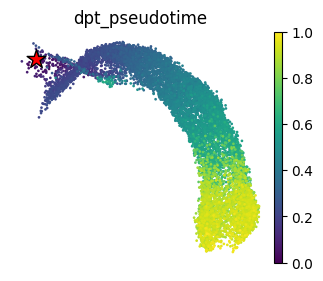

Start fitting.
Fitting NB GLMGam on all cells.
Fitting NB GLMGam for 2000 genes using n_jobs = 10...


Stored pseudo-velocity in adata.layers['pseudo_velocity'] with shape (9815, 2000)


  0%|          | 0/9815 [00:00<?, ?cells/s]

computing pseudo-velocity graph
finished.


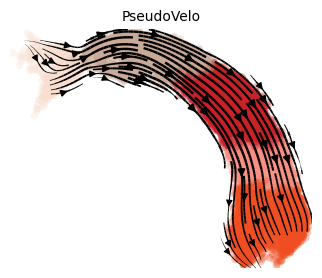

computing pseudo-velocity embedding
finished.


  0%|          | 0/9815 [00:00<?, ?cell/s]

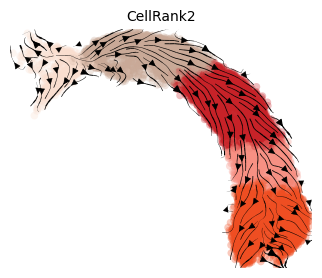

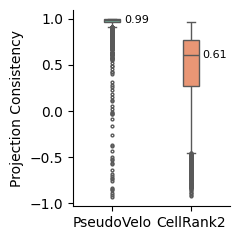

dpt_pseudotime - pv accuracy: 0.91104615
dpt_pseudotime - cr2 accuracy: 0.591385433296235


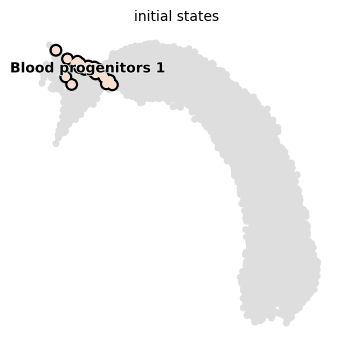

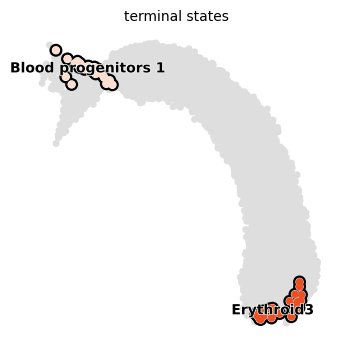

  0%|          | 0/9815 [00:00<?, ?cell/s]

  0%|          | 0/9815 [00:00<?, ?cell/s]

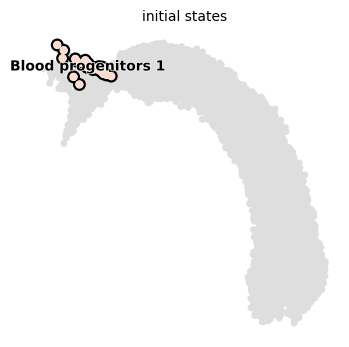

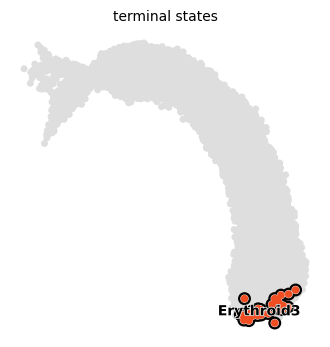

In [3]:
# 1.1 DPT Standard
adata_dpt = load_and_preprocess_data()
root_idx = find_root_index(adata_dpt, "celltype", "Blood progenitors 1")
adata_dpt, pk = run_eval_pipeline(adata_dpt, time_key="dpt_pseudotime", root_idx=root_idx)

INFO     Initialized CellMapper for self-mapping with 9815 cells.                                                  


INFO     Self-mapping mode detected. Computing only yx neighbors for efficiency (all neighbor matrices will contain
         the same information).                                                                                    


INFO     Using sklearn to compute 30 neighbors.                                                                    


INFO     Computing mapping matrix using kernel method 'umap'.                                                      


INFO     Mapping layer for key 'X' using direct multiplication                                                     


INFO     Imputed expression matrix with shape (9815, 14352) converted to AnnData object.                           
         Observation metadata from query and feature metadata from reference were linked (not copied).             


INFO     Expression for layer 'X' mapped and stored in query_imputed.X.                                            


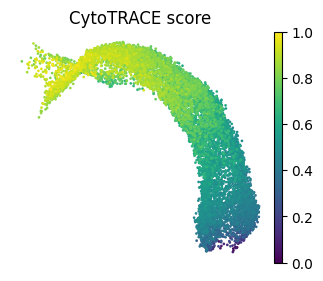

  0%|          | 0/9815 [00:00<?, ?cell/s]

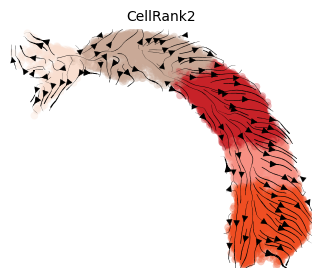

  0%|          | 0/9815 [00:00<?, ?cells/s]

computing pseudo-velocity graph
finished.


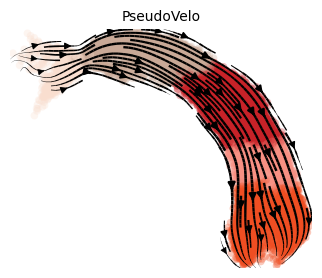

computing pseudo-velocity embedding
finished.


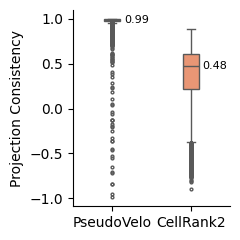

ct_pseudotime - pv accuracy: 0.86528283
ct_pseudotime - cr2 accuracy: 0.5582450766317317


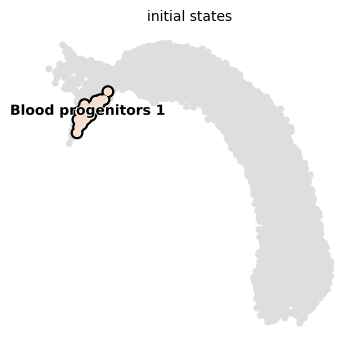

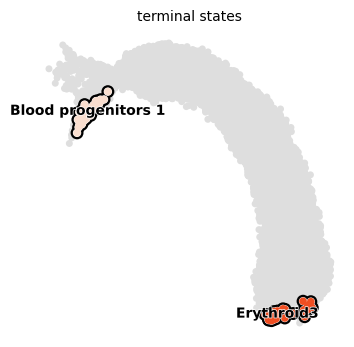

  0%|          | 0/9815 [00:00<?, ?cell/s]

  0%|          | 0/9815 [00:00<?, ?cell/s]

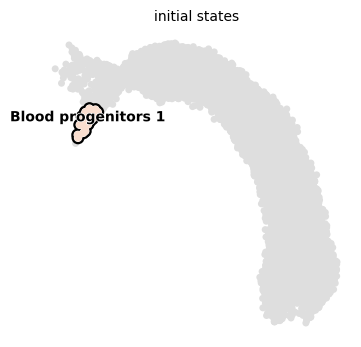

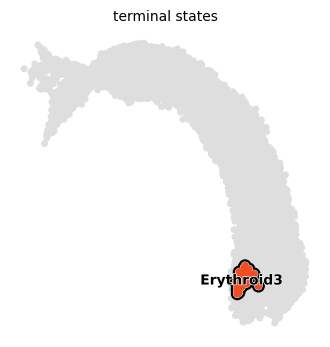

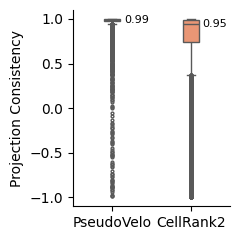

In [ ]:
# 1.2 CytoTRACE Analysis
adata_raw = sc.read_h5ad("./data/gas/MouseErythroid_anndata.h5ad")
adata_ct = adata_raw.copy()

sc.pp.filter_genes(adata_ct, min_cells=10)
sc.pp.normalize_total(adata_ct)
sc.pp.log1p(adata_ct)
sc.pp.highly_variable_genes(adata_ct, n_top_genes=2000)
sc.tl.pca(adata_ct)
sc.pp.neighbors(adata_ct, n_neighbors=30, n_pcs=30)

adata_ct.layers["imputed"] = CellMapper(adata_ct).map(layer_key="X", use_rep="X_pca").query_imputed.X.copy()
ctk = CytoTRACEKernel(adata_ct).compute_cytotrace(layer="imputed")
adata_ct.obs["1_minus_pseudotime"] = 1 - adata_ct.obs["ct_pseudotime"]

fig, ax = plt.subplots(figsize=(3.7,3))
sc.pl.embedding(adata_ct, basis="umap", color="1_minus_pseudotime", frameon=False, ax=ax, size=15, title="CytoTRACE score", legend_fontsize=8)
ctk.compute_transition_matrix()
ctk.plot_projection(basis="umap", color="celltype", figsize=(3.9,3.1), title="CellRank2", size=120, legend_loc="none", show=False)
ax = plt.gca()
ax.grid(False)
plt.show()

# Build adata for PV
adata_pv_ct = load_and_preprocess_data()
adata_pv_ct.obs["ct_pseudotime"] = adata_ct.obs["ct_pseudotime"]
adata_pv_ct, ctk = run_eval_pipeline(adata_pv_ct, time_key="ct_pseudotime", cluster_key="celltype", run_dpt=False, ctk=ctk)

# 1.3 Cross Projection Consistency
acc_cross1 = cross_projection_consistency(adata_dpt, adata_pv_ct, vkey="pseudo_velocity",embedding_key="X_umap")
acc_cross2 = cross_projection_consistency(adata1=adata_dpt,T_velo1=pk.transition_matrix, T_velo2=ctk.transition_matrix,embedding_key="X_umap")
data_list3 = [
        acc_cross1, 
        acc_cross2
    ]
plot_projection_consistency_boxplot(data_list3, labels=["PseudoVelo", "CellRank2"])

### Part 2: Robustness Analysis
Test the impact of cell subsampling and gene subsampling on the results.


--- Running Robustness: Cell Subsampling ---


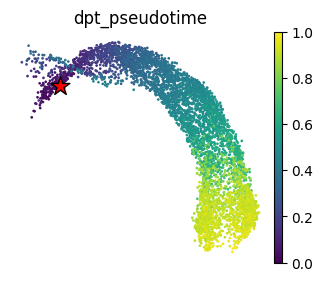

Start fitting.
Fitting NB GLMGam on all cells.
Fitting NB GLMGam for 2000 genes using n_jobs = 10...


Stored pseudo-velocity in adata.layers['pseudo_velocity'] with shape (4907, 2000)


  0%|          | 0/4907 [00:00<?, ?cells/s]

computing pseudo-velocity graph
finished.


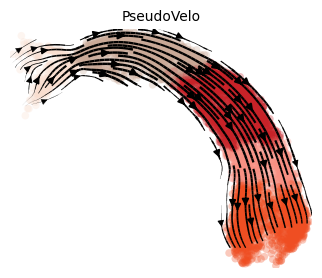

computing pseudo-velocity embedding
finished.


  0%|          | 0/4907 [00:00<?, ?cell/s]

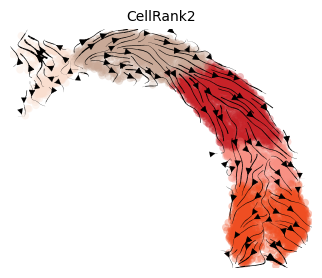

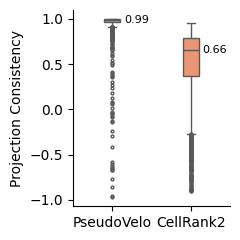

dpt_pseudotime - pv accuracy: 0.9288417
dpt_pseudotime - cr2 accuracy: 0.6034072476078068


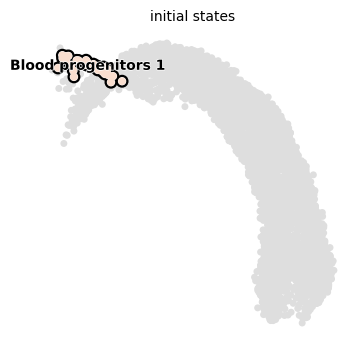

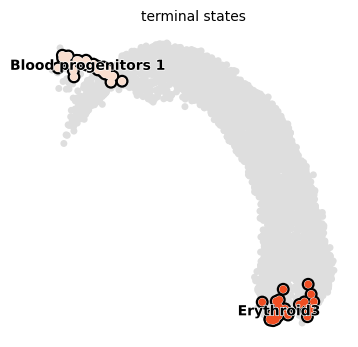

  0%|          | 0/4907 [00:00<?, ?cell/s]

  0%|          | 0/4907 [00:00<?, ?cell/s]

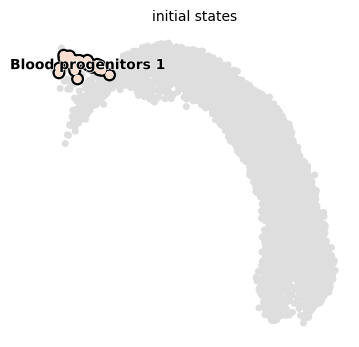

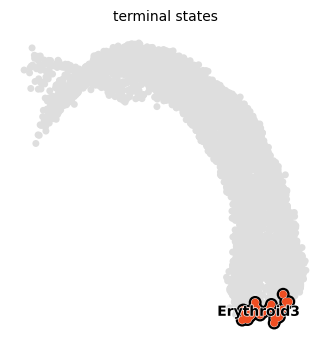

In [5]:
# 2.1 Cell Subsampling Test
print("\n--- Running Robustness: Cell Subsampling ---")
adata_rob_cell = load_and_preprocess_data(subsample_cells=True)
root_idx = find_root_index(adata_rob_cell, "celltype", "Blood progenitors 1")
_ = run_eval_pipeline(adata_rob_cell, root_idx=root_idx)


--- Running Robustness: Gene Subsampling ---


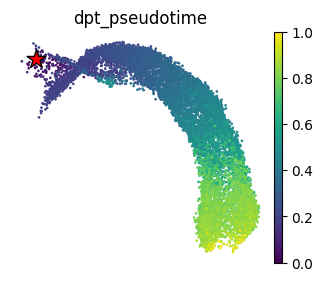

Start fitting.
Fitting NB GLMGam on all cells.
Fitting NB GLMGam for 2000 genes using n_jobs = 10...


Stored pseudo-velocity in adata.layers['pseudo_velocity'] with shape (9815, 2000)


  0%|          | 0/9815 [00:00<?, ?cells/s]

computing pseudo-velocity graph
finished.


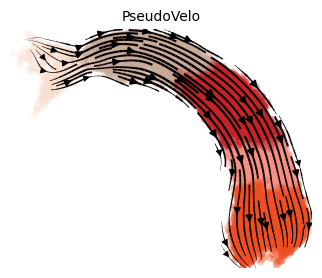

computing pseudo-velocity embedding
finished.


  0%|          | 0/9815 [00:00<?, ?cell/s]

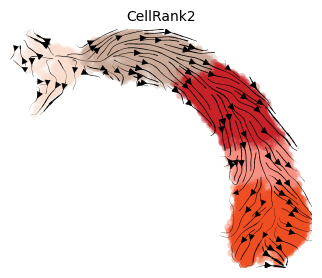

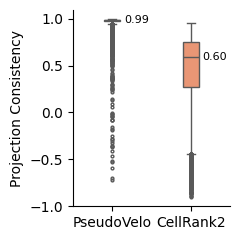

dpt_pseudotime - pv accuracy: 0.89074606
dpt_pseudotime - cr2 accuracy: 0.5939647342923013


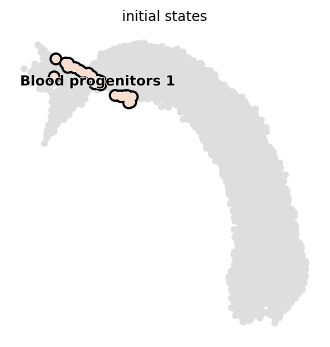

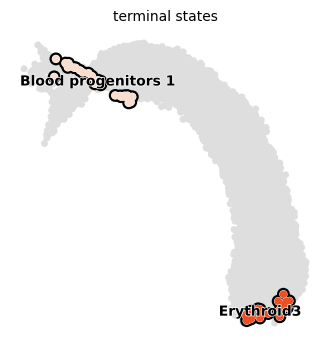

  0%|          | 0/9815 [00:00<?, ?cell/s]

  0%|          | 0/9815 [00:00<?, ?cell/s]

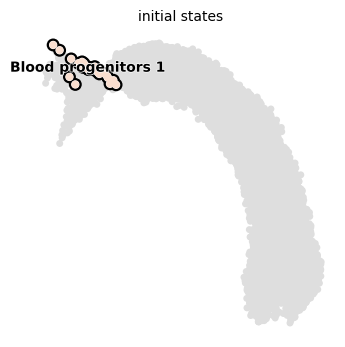

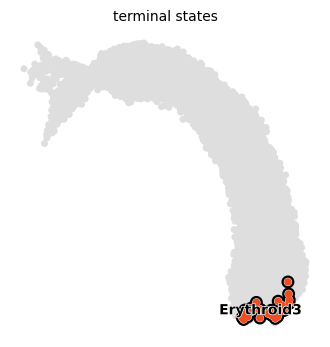

In [6]:
# 2.2 Gene Subsampling Test
print("\n--- Running Robustness: Gene Subsampling ---")
adata_rob_gene = load_and_preprocess_data(subsample_genes=True)
root_idx = find_root_index(adata_rob_gene, "celltype", "Blood progenitors 1")
_ = run_eval_pipeline(adata_rob_gene, root_idx=root_idx)